### note
from v0 (deleted, incorrect hidden state encoding)<br/>
sine, dampling testing

In [1]:
# import libraries 
import torch
import torch.nn as nn
from torch.autograd import Variable

import numpy as np
import time
import copy

import pennylane as qml
import matplotlib.pyplot as plt

import pickle

In [2]:
class QGRUCirc:
    def __call__(self, inputs, weights):
        # inputs: includes inputs and hiddens
        # inputs
        qml.RY(inputs[0]*weights[0]+weights[1], wires=0)
        # initialize hidden state
        qml.RY(inputs[1]*weights[2]+weights[3], wires=1)
        qml.RY(inputs[2]*weights[4]+weights[5], wires=2)
        qml.RY(inputs[3]*weights[6]+weights[7], wires=3)
        qml.RY(inputs[4]*weights[8]+weights[9], wires=4)
        qml.CNOT(wires=[1, 2])
        qml.CNOT(wires=[2, 3])
        qml.CNOT(wires=[3, 4])
        qml.Barrier(wires=range(5))
        # gates
        qml.CNOT(wires=[0, 1])
        qml.CSWAP(wires=[1, 2, 5])
        qml.RX(weights[10], wires=1)
        qml.CSWAP(wires=[1, 4, 6])
        qml.Barrier(wires=range(5))
        # layer 1
        qml.RX(weights[11], wires=0)
        qml.RX(weights[12], wires=1)
        qml.RX(weights[13], wires=2)
        qml.RX(weights[14], wires=3)
        qml.RX(weights[15], wires=4)
        qml.CNOT(wires=[4, 3])
        qml.CNOT(wires=[3, 2])
        qml.CNOT(wires=[2, 1])
        qml.CNOT(wires=[1, 0])
        qml.Barrier(wires=range(5))
        # layer 2
        qml.RY(weights[16], wires=0)
        qml.RY(weights[17], wires=1)
        qml.RY(weights[18], wires=2)
        qml.RY(weights[19], wires=3)
        qml.RY(weights[20], wires=4)
        qml.CNOT(wires=[4, 3])
        qml.CNOT(wires=[3, 2])
        qml.CNOT(wires=[2, 1])
        qml.CNOT(wires=[1, 0])
        
        return [qml.expval(qml.PauliZ(i)) for i in range(5)]
        

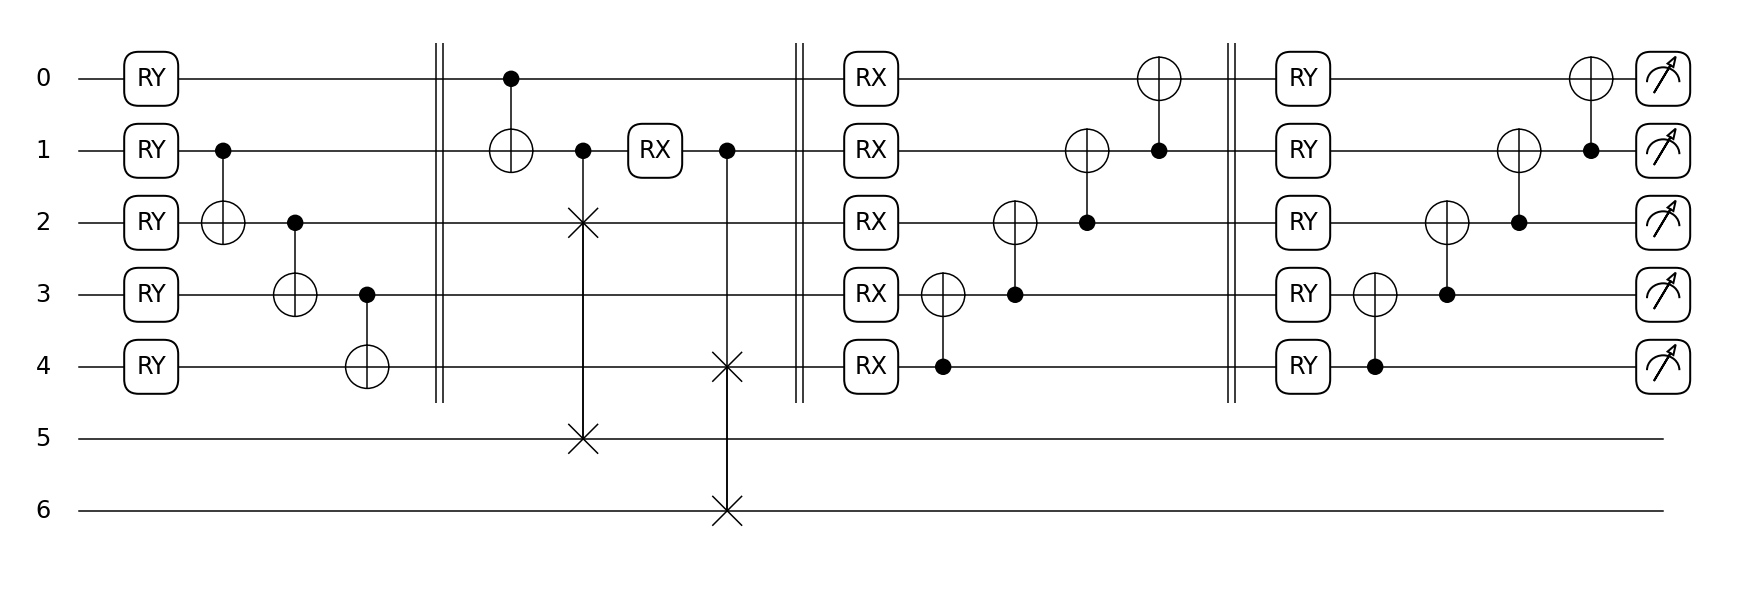

In [3]:
# https://pennylane.readthedocs.io/en/stable/code/api/pennylane.draw_mpl.html

qml.drawer.use_style('black_white')
dev = qml.device("default.qubit", wires=8)
qcirc = QGRUCirc()
qnode = qml.QNode(qcirc, dev)

fig, _ = qml.draw_mpl(qnode, fontsize=24)(range(5),range(21))

In [4]:
#class QNode(func, device, interface='autograd', diff_method='best', mutable=True,
#max_expansion=10, h=1e-07, order=1, shift=1.5707963267948966, adjoint_cache=True, argnum=None, **kwargs)

class QGRU(nn.Module):
    def __init__(self):
        super(QGRU, self).__init__()
        
        dev = qml.device("default.qubit", wires=7)
        circuit = QGRUCirc()
        qnode = qml.QNode(circuit, dev)
        
        self.weight_shapes = {"weights": 21}
        self.qgru = qml.qnn.TorchLayer(qnode, self.weight_shapes)
        self.hidden_size = 4
                
    def forward(self, inputs, hiddens=None):
        # Currently, input dim=1, hidden dim=5
        
        if len(inputs.size()) == 1:
            if hiddens == None:
                hiddens = torch.zeros(self.hidden_size)
            Xs = torch.cat((inputs, hiddens))
        else:
            if hiddens == None:
                hiddens = torch.zeros([inputs.size(0), self.hidden_size])
            Xs = torch.cat((inputs, hiddens), 1)
        
        return self.qgru(Xs) # Currently, output dim=5
    

## Sequence (to make a RNN)

In [5]:
class Sequence(nn.Module):
    def __init__(self, initial_weight=None):
        super(Sequence, self).__init__()
        
        self.qgru = QGRU()
        self.out_size = 1
#         self.h_0 = torch.zeros(self.qgru.num_of_hidden)

    def forward(self, inputs, future = 0):
        # inputs: tensor
        # [[a1, a2, a3, ...]...] or [[[a1, a2, a3, ...]...]...]
        
        single = len(inputs.size()) == 2
        
        if single:
            inputs = torch.unsqueeze(inputs, 0)
        
        ht = None
        outSeq = torch.tensor([])
        
        for Xs in torch.transpose(inputs, 0, 1):
            Ys = self.qgru(Xs, ht)
            outs = Ys[:, :self.out_size]
            ht = Ys[:, self.out_size:]
            outSeq = torch.cat((outSeq, torch.unsqueeze(outs, 1)), 1)
            
        # future: only for the same types of input and output
        # the last outputs are used fot next inputs
        for _ in range(future):
            Ys = self.qgru(outs, ht)
            outs = Ys[:, :self.out_size]
            ht = Ys[:, self.out_size:]
            outSeq = torch.cat((outSeq, torch.unsqueeze(outs, 1)), 1)
            
        if single:
            outSeq = outSeq[0]
            
        return outSeq
   

## Sine

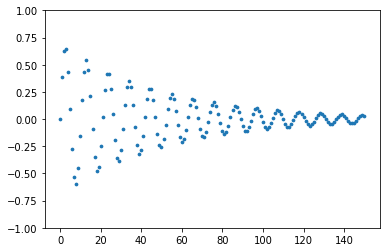

In [6]:
# ys = ((torch.tensor([np.sin(_*0.5) for _ in range(151)])*0.5)).float()
ys = ((torch.tensor([np.sin(_*0.6)*np.exp(_*-0.02) for _ in range(151)])*0.7)).float()
testInput = ys[:-51]
testTarget = ys[1:len(testInput)+1]

testInput = testInput.reshape([len(testInput),1])
testTarget = testTarget.reshape([len(testTarget),1])

testInput_a = ys[:-1]
testInput_a = testInput_a.reshape([len(testInput_a),1])

# print('input:', testInput)
# print('target:', testTarget)
plt.scatter(range(len(ys)), ys, s=3)
plt.ylim(-1,1)
plt.show()

In [7]:
seeds = [np.random.randint(0, 1000) for _ in range(10)]
seeds = [847, 288, 794, 108, 945, 471, 300, 813, 359, 445]
seeds

[847, 288, 794, 108, 945, 471, 300, 813, 359, 445]

In [8]:
def test(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    model = Sequence()

    start_time = time.time()
    criterion = torch.nn.MSELoss(reduction='mean')
    optimizer = torch.optim.Adam(model.parameters(), lr=0.05)
    minLoss = 100000
    lossList = []

    for t in range(1000):
        prediction = model.forward(testInput)

        # Compute and print loss
        loss = criterion(prediction, testTarget)
        if loss.item() <= minLoss:
            minLoss = loss.item()
            best_state = copy.deepcopy(model.state_dict())

        curtime = time.time()
        print('{}: {}  {}       '.format(t, loss.item(), curtime-start_time), end='\r')
        if t % 10 == 9:
            print('{}: {}  {}       '.format(t, loss.item(), curtime-start_time))
            lossList.append(loss.item())

        # Zero gradients, perform a backward pass, and update the weights.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    return lossList, best_state

In [9]:
def plotPNG(seed, loss, bState):
    plt.clf()
    plt.plot([x*10 for x in range(len(loss))], loss)
    plt.ylabel('Loss')
    plt.xlabel('Step')
    plt.yscale("log")
    plt.savefig('loss_' + str(seed) + '.png')
    
    best_model = Sequence()
    best_model.load_state_dict(bState)
    bestPredict = best_model(testInput, 50).detach()
    
    bp = bestPredict.tolist()
    ta = testTarget.tolist()
    tb = ys[len(testInput)+1:].tolist()
    plt.clf()
    plt.scatter(range(len(ta)), ta, c='b', s=3)
    plt.scatter(np.array(range(len(tb)))+len(ta), tb, c='r', s=3)
    plt.plot(bp, c='g')
    plt.ylim(-1,1)
    plt.savefig('result_' + str(seed) + '.png')
    

9: 0.045895811170339584  22.03454327583313        
19: 0.0319487564265728  46.984381675720215         
29: 0.020505720749497414  75.95544981956482        
39: 0.014647454023361206  106.09955215454102       
49: 0.01236005499958992  135.7184898853302         
59: 0.011346111074090004  164.94606137275696       
69: 0.010491547174751759  194.24597549438477       
79: 0.009701846167445183  223.3784441947937        
89: 0.009413243271410465  251.75614547729492       
99: 0.008337515406310558  279.6920094490051        
109: 0.008107933215796947  308.4466247558594        
119: 0.008023444563150406  336.108357667923         
129: 0.007596846204251051  363.9589047431946        
139: 0.007342783268541098  391.56121706962585       
149: 0.007308406755328178  419.77667450904846       
159: 0.007184477988630533  447.4701883792877        
169: 0.007368737366050482  476.0326597690582        
179: 0.007898425683379173  504.4150125980377        
189: 0.007259298115968704  533.4530191421509        
199:

59: 0.05491941422224045  130.01029706001282        
69: 0.056085530668497086  152.2866723537445       
79: 0.05380439758300781  175.14224195480347       
89: 0.04477100074291229  197.475017786026          
99: 0.03941107913851738  219.62307143211365        
109: 0.035854071378707886  241.09191417694092       
119: 0.032878704369068146  262.7881646156311        
129: 0.030619041994214058  284.25017642974854       
139: 0.028967764228582382  305.43258905410767       
149: 0.02776130847632885  327.47875809669495        
159: 0.026827817782759666  349.2674880027771        
169: 0.0260561965405941  370.68622851371765         
179: 0.025377146899700165  392.6610600948334        
189: 0.02473793737590313  413.1659688949585         
199: 0.02409808337688446  434.45760202407837        
209: 0.023424038663506508  456.4745395183563        
219: 0.022689420729875565  477.6408112049103        
229: 0.021880142390727997  498.3935523033142        
239: 0.0210036039352417  519.4031054973602          


139: 0.010470470413565636  301.89093828201294       
149: 0.009995680302381516  323.4494993686676        
159: 0.008555125445127487  344.1618492603302        
169: 0.01015830785036087  365.2466514110565         
179: 0.009349234402179718  385.4048111438751        
189: 0.007667266298085451  405.9159264564514        
199: 0.007365312427282333  426.3948531150818        
209: 0.007001061923801899  447.9714105129242         
219: 0.00702373031526804  468.63866090774536         
229: 0.010417214594781399  489.55235743522644       
239: 0.010113513097167015  510.26735258102417       
249: 0.009068507701158524  530.5583980083466       
259: 0.007370247971266508  551.7737293243408        
269: 0.006358438637107611  571.9722332954407        
279: 0.006623583380132914  593.2912154197693       
289: 0.007026239763945341  614.287511587143         
299: 0.006695004180073738  633.9290051460266        
309: 0.006295159459114075  653.8669078350067        
319: 0.00607884069904685  675.7257966995239   

209: 0.07820688188076019  446.03840374946594       
219: 0.07820688188076019  467.74115228652954       
229: 0.07820688188076019  488.5753571987152        
239: 0.07820688188076019  510.2973937988281        
249: 0.07820688188076019  532.1211204528809       
259: 0.07820688188076019  553.4236195087433       
269: 0.07820688188076019  575.3689348697662       
279: 0.07820688188076019  597.2296032905579       
289: 0.07820688188076019  618.7346816062927       
299: 0.07820688188076019  640.4536340236664       
309: 0.07820688188076019  662.2659347057343       
319: 0.07820688188076019  683.5050032138824       
329: 0.07820688188076019  704.6871783733368       
339: 0.07820688188076019  725.5105090141296       
349: 0.07820688188076019  746.8742306232452       
359: 0.07820688188076019  767.6490979194641       
369: 0.07820688188076019  788.1247363090515       
379: 0.07820688188076019  809.5277333259583       
389: 0.07820688188076019  830.4732999801636       
399: 0.07820688188076019  8

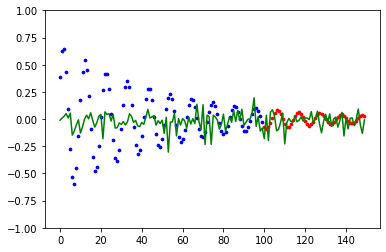

In [26]:
lossA = []
bStateA = []
for seed in seeds:
    loss, bState = test(seed)
    lossA.append(loss)
    bStateA.append(bState)
    
    # plot to file
    plotPNG(seed, loss, bState)

In [11]:
seeds[6]

300

In [12]:
bState = bStateA[6]

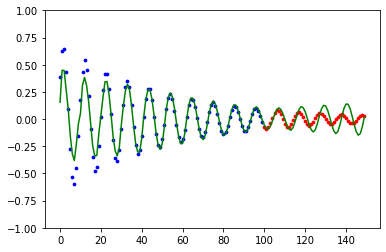

In [13]:
best_model = Sequence()
best_model.load_state_dict(bState)
bestPredict = best_model(testInput, 50).detach()

bp = bestPredict.tolist()
ta = testTarget.tolist()
tb = ys[len(testInput)+1:].tolist()
plt.scatter(range(len(ta)), ta, c='b', s=3)
plt.scatter(np.array(range(len(tb)))+len(ta), tb, c='r', s=3)
plt.plot(bp, c='g')
plt.ylim(-1,1)
plt.show()

In [21]:
# ys2 = ((torch.tensor([np.sin(_*0.5) for _ in range(151)])*0.5)).float()
ys2 = ((torch.tensor([np.sin(_*0.55)*np.exp(_*0.01) for _ in range(151)])*0.2)).float()
testInput2 = ys2[:-51]
testTarget2 = ys2[1:len(testInput)+1]

testInput2 = testInput2.reshape([len(testInput2),1])
testTarget2 = testTarget2.reshape([len(testTarget2),1])

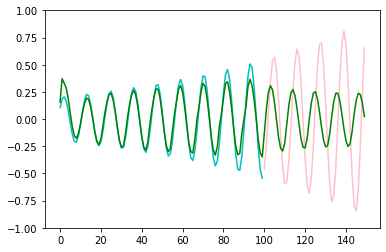

In [22]:
best_model = Sequence()
best_model.load_state_dict(bState)
bestPredict2 = best_model(testInput2, 50).detach()

bp2 = bestPredict2.tolist()
ta2 = testTarget2.tolist()
tb2 = ys2[len(testInput2)+1:].tolist()
plt.plot(range(len(ta2)), ta2, c='c')
plt.plot(np.array(range(len(tb2)))+len(ta2), tb2, c='pink')
plt.plot(bp2, c='g')
plt.ylim(-1,1)
plt.show()

In [33]:
with open('lossA.pickle', 'wb') as f:
    pickle.dump(lossA, f)
with open('bStateA.pickle', 'wb') as f:
    pickle.dump(bStateA, f)

In [10]:
with open('bStateA.pickle', 'rb') as f:
    bStateA = pickle.load(f)